# Predicting Coral Bleaching Severity Using Machine Learning
**Cody Le | CSUF Summer Research Program 2026**

This notebook builds a machine learning pipeline to predict coral bleaching severity 
using a dataset of 34,000+ reef observations from 93 countries spanning 1980–2020. 
The pipeline covers data cleaning, exploratory data analysis, a baseline linear 
regression model, and a neural network built with TensorFlow.

## Step 1: Data Cleaning
The raw dataset contained 41,361 rows and 62 columns. Steps taken:
- Selected 26 relevant features from the original 62 columns
- Resolved "nd" placeholder values across 19 numeric columns
- Dropped rows missing the target variable (`Percent_Bleaching`) and any remaining numeric fields
- Final cleaned dataset: 32,714 rows, 0 missing values

In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv('coral.csv')

# Cleaning, removing unneccessary columns

columns_to_keep = [
    'Percent_Bleaching', 
    'ClimSST', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
    'SSTA', 'SSTA_Mean', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_DHW',
    'TSA', 'TSA_Mean', 'TSA_Maximum', 'TSA_Frequency', 'TSA_DHW',
    'Turbidity', 'Windspeed', 'Depth_m', 'Distance_to_Shore', 'Exposure',
    'Date_Year', 'Date_Month', 'Country_Name', 'Ocean_Name',
    'Latitude_Degrees', 'Longitude_Degrees'
]

df = df[columns_to_keep]

# List of columns that should be numeric but are being read as text
columns_to_fix = [
    'ClimSST', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
    'SSTA', 'SSTA_Mean', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_DHW',
    'TSA', 'TSA_Mean', 'TSA_Maximum', 'TSA_Frequency', 'TSA_DHW',
    'Windspeed', 'Depth_m'
]


# Missing values in Percent Bleaching, Turbidity, and Distance_to_Shore, locate missing rows and remove them

# Replace 'nd' with actual NaN, then convert column to numeric since null percent_bleaching is inconsistent
df['Percent_Bleaching'] = df['Percent_Bleaching'].replace('nd', np.nan)
df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'])

# Do the same thing w Turbidity
df['Turbidity'] = df['Turbidity'].replace('nd', np.nan)
df['Turbidity'] = pd.to_numeric(df['Turbidity'])

# Do the same thing w Distance_To_Shore
df['Distance_to_Shore'] = df['Distance_to_Shore'].replace('nd', np.nan)
df['Distance_to_Shore'] = pd.to_numeric(df['Distance_to_Shore'])

# Drop rows where the target variable is missing
df = df.dropna(subset=['Percent_Bleaching'])
df = df.dropna(subset=['Turbidity'])
df = df.dropna(subset=['Distance_to_Shore'])

# Check missing values across all remaining columns

for col in columns_to_fix:
    df[col] = df[col].replace('nd', np.nan)
    df[col] = pd.to_numeric(df[col])

df = df.dropna(subset=columns_to_fix)

print(df.isnull().sum().to_string())
print(df.shape)



# Update CSV
df.to_csv('coral_clean.csv', index=False)


C:\Users\codyl\AppData\Local\Temp\ipykernel_21444\2990731407.py:4: DtypeWarning: Columns (0: Distance_to_Shore, 1: Turbidity, 2: Percent_Bleaching) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('coral.csv')


Percent_Bleaching      0
ClimSST                0
Temperature_Mean       0
Temperature_Minimum    0
Temperature_Maximum    0
SSTA                   0
SSTA_Mean              0
SSTA_Maximum           0
SSTA_Frequency         0
SSTA_DHW               0
TSA                    0
TSA_Mean               0
TSA_Maximum            0
TSA_Frequency          0
TSA_DHW                0
Turbidity              0
Windspeed              0
Depth_m                0
Distance_to_Shore      0
Exposure               0
Date_Year              0
Date_Month             0
Country_Name           0
Ocean_Name             0
Latitude_Degrees       0
Longitude_Degrees      0
(32714, 26)


## Step 2: Exploratory Data Analysis (EDA)
Before modeling, I'll explore the dataset to understand the distribution of the target 
variable, relationships between features, and regional/temporal patterns in bleaching severity.

### Distribution of Coral Bleaching Severity Histogram
The target variable `Percent_Bleaching` is heavily right-skewed, with the majority of 
observations recording little to no bleaching. Severe bleaching events are relatively 
rare compared to healthy reef observations.

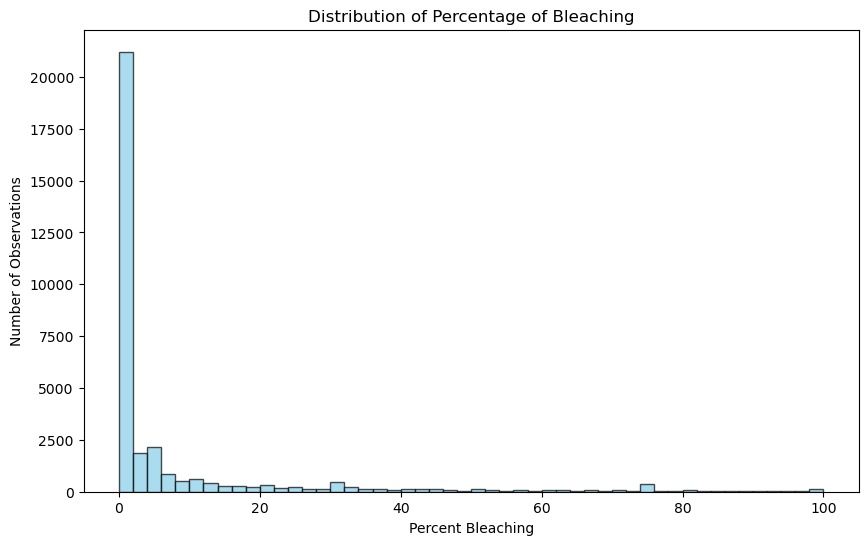

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determine number of Percentage of Bleaching observations using a histogram
plt.figure(figsize=(10,6))

plt.hist(df['Percent_Bleaching'], bins=50, color="skyblue", edgecolor="black", alpha=0.7)
plt.title('Distribution of Percentage of Bleaching')
plt.xlabel('Percent Bleaching')
plt.ylabel('Number of Observations')
plt.show()

# Looks like most observations have 0% bleaching. Small spike around 75%.


### Correlation Matrix of Coral Bleaching Features
Temperature variables (ClimSST, Temperature_Mean, etc.) and heat stress metrics 
(SSTA_DHW, TSA_DHW, etc.) form distinct clusters, indicating high collinearity within 
each group. No single feature shows a strong individual correlation with `Percent_Bleaching`, 
suggesting bleaching severity is driven by complex interactions between multiple variables.

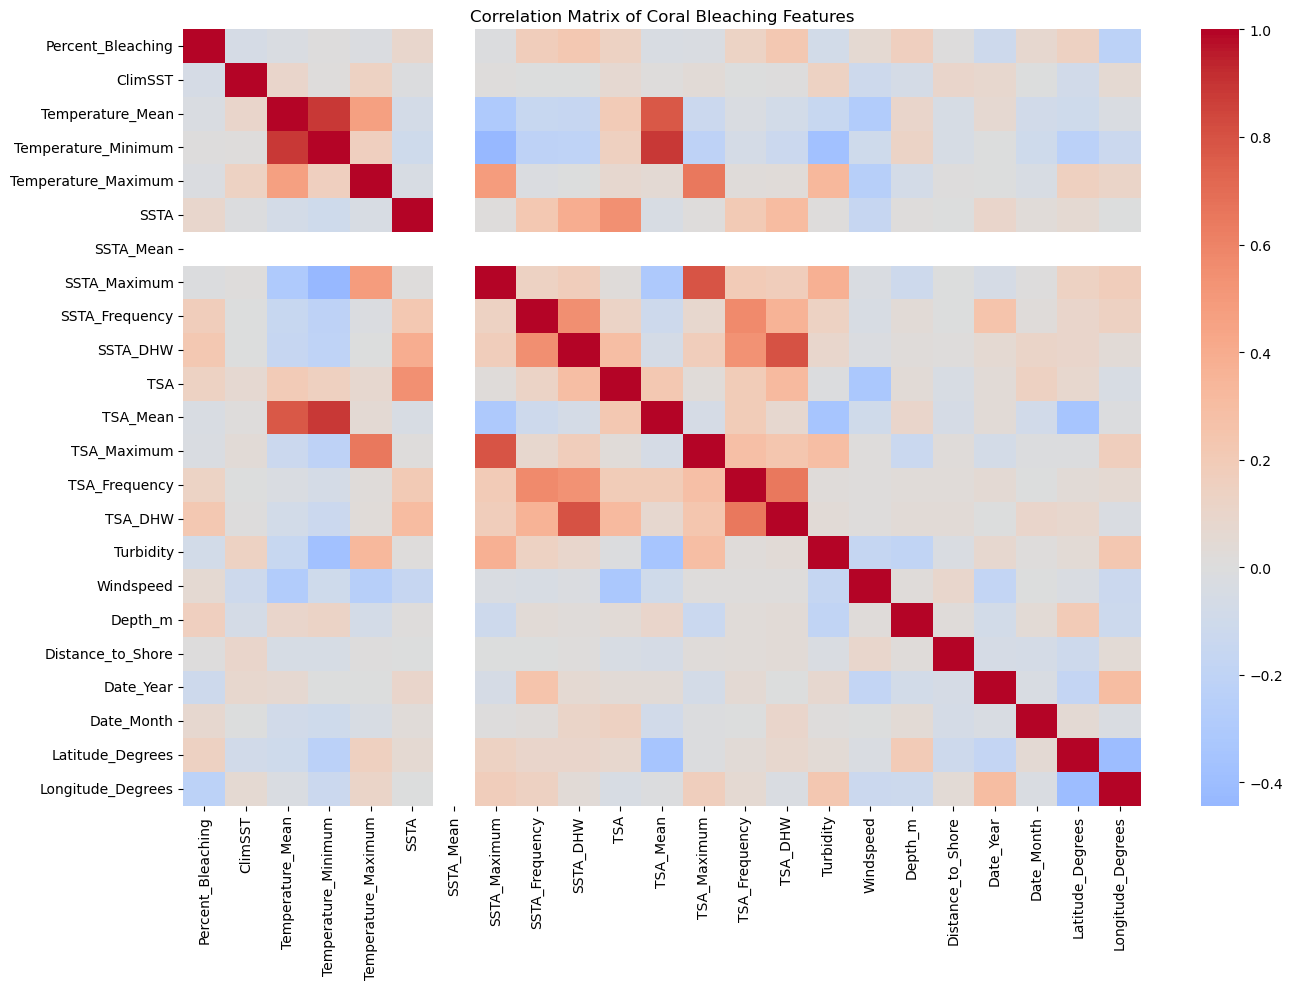

In [27]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), 
            annot=False, 
            cmap='coolwarm',
            center=0)
plt.title('Correlation Matrix of Coral Bleaching Features')
plt.tight_layout()
plt.show()

### Average Bleaching Severity Over Time
Average bleaching percentage is plotted across all survey years from 1980 to 2020 
to identify any long-term trends in reef health over time.

**Note:** The number of monitored reef sites increased significantly after 2000, meaning 
early years represent far fewer observations. The apparent decline in average bleaching 
over time likely reflects this sampling bias rather than genuine ecological recovery.

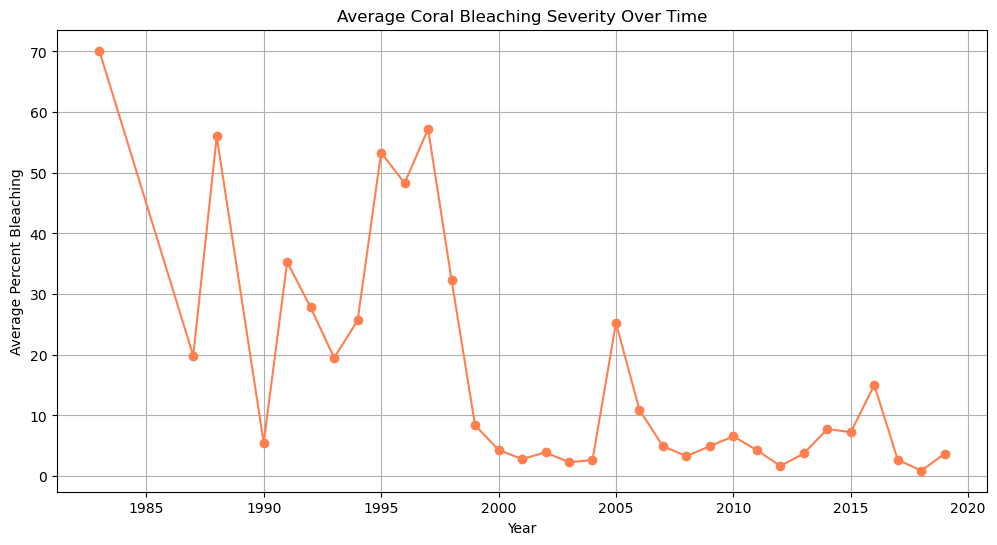

In [28]:
yearly_bleaching = df.groupby('Date_Year')['Percent_Bleaching'].mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_bleaching.index, yearly_bleaching.values, color='coral', marker='o')
plt.title('Average Coral Bleaching Severity Over Time')
plt.xlabel('Year')
plt.ylabel('Average Percent Bleaching')
plt.grid(True)
plt.show()

### Average Bleaching Severity by Ocean Region
The Atlantic and Indian Oceans show the highest average bleaching severity. The Pacific's 
lower average is likely influenced by the large volume of observations from diverse reef 
sites, many of which recorded low bleaching values.

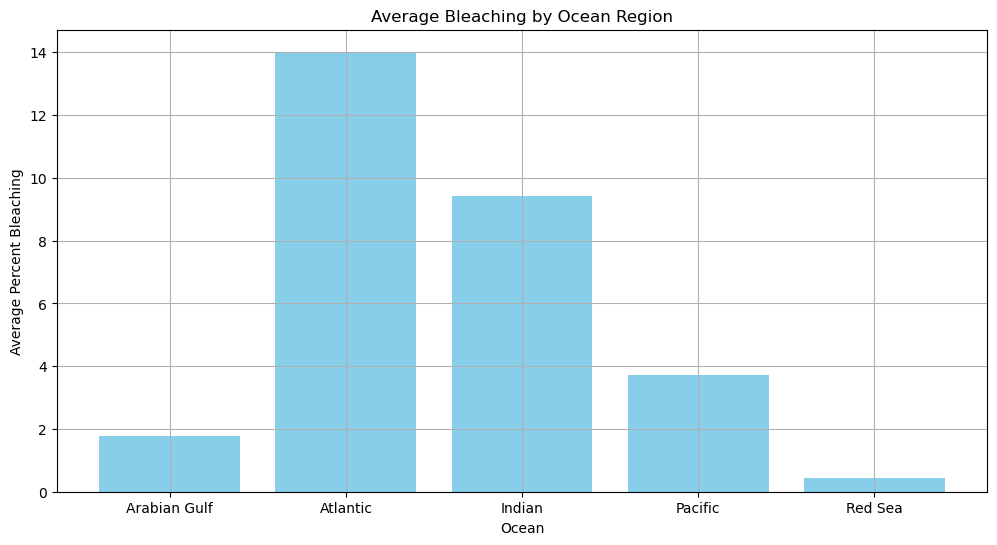

In [29]:
bleaching_by_ocean = df.groupby('Ocean_Name')['Percent_Bleaching'].mean()

plt.figure(figsize=(12,6))
plt.bar(bleaching_by_ocean.index, bleaching_by_ocean.values, color='skyblue')
plt.xlabel('Ocean')
plt.ylabel('Average Percent Bleaching')
plt.title('Average Bleaching by Ocean Region')
plt.grid(True)
plt.show()

### Sea Surface Temperature vs. Bleaching Severity
No clear linear relationship is observed between mean sea surface temperature and bleaching 
percentage, reinforcing that temperature alone is insufficient to predict bleaching severity.

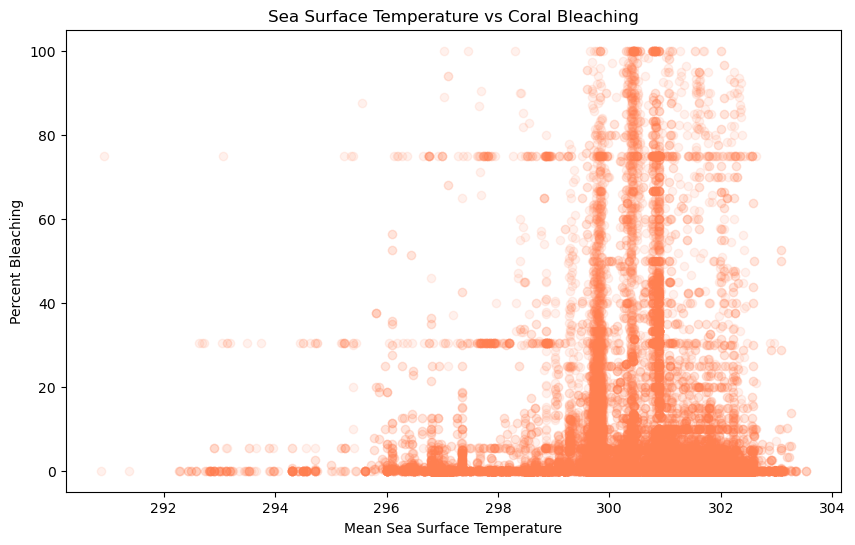

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Temperature_Mean'], df['Percent_Bleaching'], alpha=0.1, color='coral')
plt.xlabel('Mean Sea Surface Temperature')
plt.ylabel('Percent Bleaching')
plt.title('Sea Surface Temperature vs Coral Bleaching')
plt.show()

### Degree Heating Weeks (SSTA_DHW) vs. Bleaching Severity
Degree Heating Weeks is one of the most scientifically recognized predictors of coral 
bleaching. While most observations cluster near 0 DHW, the scatter shows no clean linear 
trend, further motivating the use of a neural network over a simple linear model.

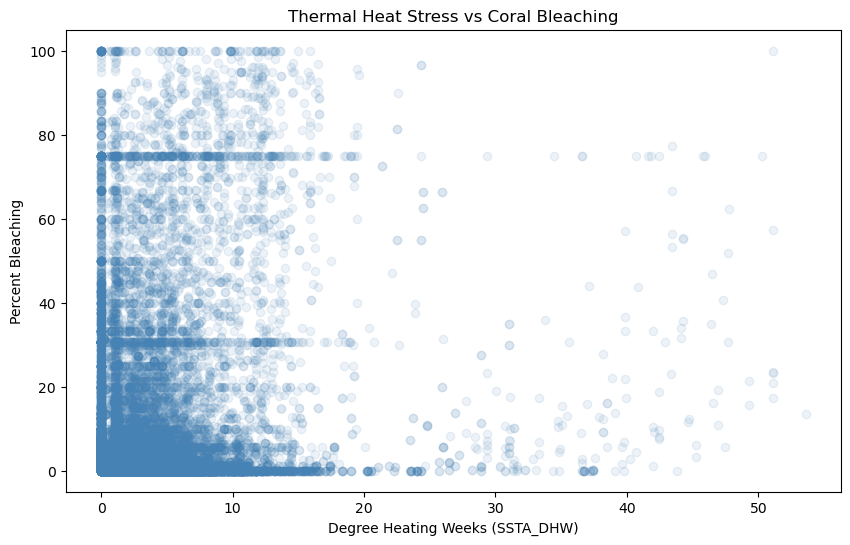

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(df['SSTA_DHW'], df['Percent_Bleaching'], alpha=0.1, color='steelblue')
plt.xlabel('Degree Heating Weeks (SSTA_DHW)')
plt.ylabel('Percent Bleaching')
plt.title('Thermal Heat Stress vs Coral Bleaching')
plt.show()

## Step 3: Baseline Model - Linear Regression
A linear regression model is trained as a baseline to evaluate the minimum predictive 
performance. All categorical features are excluded and numeric features are standardized 
using StandardScaler. Performance is evaluated using RMSE and MAE.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# Split data
X = df.drop(columns=['Percent_Bleaching', 'Country_Name', 'Ocean_Name', 'Exposure']) # All the columns except these ones
y = df['Percent_Bleaching']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

# Scaling the Data
scaler = StandardScaler()
scaler.fit(X_train)

# Transform the data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Run Linear Regression and Evaluate Results using RMSE and MAE
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_RMSE = root_mean_squared_error(y_test, y_pred)
y_pred_MAE = mean_absolute_error(y_test, y_pred)

print(f'RMSE: {y_pred_RMSE:.2f}')
print(f'MAE: {y_pred_MAE:.2f}')







RMSE: 15.94
MAE: 9.77


## Step 4: Neural Network — TensorFlow/Keras
A neural network is built using TensorFlow to capture the complex, non-linear 
relationships between environmental features and bleaching severity that the linear 
regression model cannot. Performance is compared against the baseline using RMSE and MAE.